In [ ]:
"""Conditional empirical-posterior regression from observed (x, y) pairs only.

A uniform cloud of candidate y values is transported by one particle Transformer.
For each observed training pair (x, y*), x is treated as the centre of a configurable
Gaussian empirical likelihood p(x_lik | y*) and the transport is conditioned on a fresh
x_lik draw. The empirical energy score trains the full y cloud. Its mean is the point
prediction; its empirical quantiles are uncertainty intervals.

Retained from bayes-transport:
  * uniform base prior;
  * shared-tau interpolated training priors;
  * Gaussian-noisified x likelihood observations from the supplied data pairs;
  * historical-output replay buffer;
  * identity-initialised particle transport;
  * empirical energy score and cloud diagnostics.

Removed:
  * simulator / synthetic (x,y) generation;
  * dimension and likelihood embedders;
  * observation prefixes / recurrent Bayes rollouts;
  * DEQ / fixed-point / drifting modes;
  * heterogeneous shapes and padding.

The bottom of the file trains the same-condition MLP and GP baselines and both saves
and displays a three-way comparison on exactly the data/split used by nn.py and gp.py.
"""
from __future__ import annotations

from collections import deque
from dataclasses import asdict, dataclass
import json
from pathlib import Path
from typing import Any

try:
    from IPython.display import display as ipy_display
except ImportError:  # Plain Python scripts still work outside Jupyter.
    ipy_display = None

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, DotProduct, RBF, WhiteKernel

import seaborn as sns
sns.set_theme(style="whitegrid", rc={"figure.facecolor": "white", "axes.facecolor": "white"})
plt.rcParams.update({
    "mathtext.fontset": "stix",
    "font.family": "DejaVu Sans",
    "axes.titlepad": 8.0,
    "axes.labelpad": 6.0,
})

Array = jax.Array

In [ ]:
@dataclass
class Config:
    seed: int = 2028
    data_samples: int = 2000
    noise_std: float = 0.005
    segments: int = 11
    x_range: tuple[float, float] = (-1.5, 1.5)
    train_seg_ids: tuple[int, ...] = (2, 3, 4, 5, 6, 7, 8)

    # Particle transport.
    num_particles: int = 16
    eval_particles: int = 256
    hidden_dim: int = 64
    heads: int = 4
    mlp_ratio: int = 4
    posterior_depth: int = 3
    posterior_conditioning: str = "adaln"  # {"adaln", "cross_attention"}
    cross_attention_tokens: int = 1  # learned x-memory tokens when cross-attention is selected
    max_normalized_displacement: float = 5.0

    # Training: one epoch = one observed-data minibatch / optimizer step.
    epochs: int = 5000
    batch_size: int = 64*4
    learning_rate: float = 1e-4
    weight_decay: float = 1e-5
    grad_clip_norm: float = 5.0
    log_every: int = 250

    # ONE widest uniform y-prior support. Fresh training interpolation clouds always
    # come from this support. Evaluation may reuse it, use a nearest-training local prior,
    # or use the default cheating/oracle prior centred on the known test label.
    prior_min: float = -2.0
    prior_max: float = 2.0

    # Empirical likelihood attached to each supplied training pair:
    #     x_lik ~ Normal(x_pair, likelihood_x_noise_std^2).
    # The noisy draw x_lik, not the clean pair centre x_pair, conditions the transport.
    # Replay stores the exact realised x_lik so the same evidence can be reused later.
    likelihood_x_noise_std: float = 0.01

    # Evaluation/deployment prior.
    #   "cheating" (DEFAULT): oracle/domain-expert mode. The true evaluation label y* is
    #       assumed known and defines the prior centre. The prior full width is
    #       cheating_prior_width_fraction times the widest pre-interpolation training width.
    #       With prior=[-2,2] and fraction=0.5, this gives U(y*-1, y*+1).
    #   "widest": reuse the full configured training support.
    #   "nearest_training": infer a local support only from nearby known training (x,y) pairs.
    evaluation_prior_mode: str = "cheating"  # {"cheating", "widest", "nearest_training"}
    cheating_prior_width_fraction: float = 0.50
    eval_local_prior_k: int = 64
    eval_local_prior_margin: float = 0.25
    eval_local_prior_min_width: float = 1.00
    eval_local_prior_clip_to_global: bool = True

    # Shared-tau interpolation. Strict supervised default is 0: no y* enters the input cloud.
    # Set to 1 to reproduce the original truth-anchored Bayes-transport interpolation ablation.
    truth_anchor_probability: float = 1.0

    # Historical model-output prior replay.
    historical_output_prior_probability: float = 0.50
    historical_output_buffer_capacity: int = 2048

    # Empirical interval extracted from the transported cloud.
    interval_low_q: float = 0.025
    interval_high_q: float = 0.975
    eval_batch_size: int = 256

    # Attached nn.py baseline.
    nn_hidden_size: int = 64
    nn_learning_rate: float = 1e-3
    nn_epochs: int = 3000

    # Attached gp.py baseline.
    gp_restarts: int = 10

    # Plotting. Figures are always saved; when True they are also rendered inline in notebooks.
    show_plots: bool = True

    output_dir: str = "plots/cosine_transport"


CFG = Config()


def validate_config(cfg: Config) -> None:
    if cfg.num_particles < 2 or cfg.eval_particles < 2:
        raise ValueError("Particle counts must be >= 2.")
    if cfg.hidden_dim % cfg.heads != 0:
        raise ValueError("hidden_dim must be divisible by heads.")
    if cfg.posterior_conditioning not in {"adaln", "cross_attention"}:
        raise ValueError("posterior_conditioning must be 'adaln' or 'cross_attention'.")
    if cfg.cross_attention_tokens < 1:
        raise ValueError("cross_attention_tokens must be >= 1.")
    if not 0.0 <= cfg.truth_anchor_probability <= 1.0:
        raise ValueError("truth_anchor_probability must lie in [0,1].")
    if not 0.0 <= cfg.historical_output_prior_probability <= 1.0:
        raise ValueError("historical_output_prior_probability must lie in [0,1].")
    if not cfg.prior_min < cfg.prior_max:
        raise ValueError("prior_min must be strictly smaller than prior_max.")
    if cfg.likelihood_x_noise_std <= 0.0:
        raise ValueError("likelihood_x_noise_std must be > 0 for a non-degenerate Gaussian likelihood.")
    if cfg.evaluation_prior_mode not in {"cheating", "widest", "nearest_training"}:
        raise ValueError(
            "evaluation_prior_mode must be 'cheating', 'widest', or 'nearest_training'."
        )
    if not 0.0 < cfg.cheating_prior_width_fraction <= 1.0:
        raise ValueError("cheating_prior_width_fraction must lie in (0,1].")
    if cfg.eval_local_prior_k < 1:
        raise ValueError("eval_local_prior_k must be >= 1.")
    if cfg.eval_local_prior_margin < 0.0:
        raise ValueError("eval_local_prior_margin must be >= 0.")
    if cfg.eval_local_prior_min_width <= 0.0:
        raise ValueError("eval_local_prior_min_width must be > 0.")


def gen_data(cfg: Config = CFG) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Exactly the data law and segment split in the attached baselines."""
    np.random.seed(cfg.seed)
    x_min, x_max = cfg.x_range
    x = np.random.uniform(x_min, x_max, cfg.data_samples)
    y = np.cos(10.0 * x) + 0.5 * x
    y += np.random.normal(0.0, cfg.noise_std, cfg.data_samples)
    bins = np.linspace(x_min, x_max, cfg.segments + 1)
    segs = np.clip(np.digitize(x, bins) - 1, 0, cfg.segments - 1)
    train = np.isin(segs, cfg.train_seg_ids)
    return x[train], y[train], x[~train], y[~train]


@dataclass(frozen=True)
class Scaling:
    x_center: float
    x_scale: float
    y_center: float
    y_scale: float
    prior_low: float
    prior_high: float


def make_scaling(x_train: np.ndarray, y_train: np.ndarray, cfg: Config = CFG) -> Scaling:
    """Normalization derived from x_train and the manually configured global y-prior support."""
    del y_train  # y targets do not determine the prior support.
    x_lo, x_hi = float(x_train.min()), float(x_train.max())
    prior_low, prior_high = float(cfg.prior_min), float(cfg.prior_max)
    y_center = 0.5 * (prior_low + prior_high)
    y_half = max(0.5 * (prior_high - prior_low), 1e-6)
    return Scaling(
        x_center=0.5 * (x_lo + x_hi),
        x_scale=max(0.5 * (x_hi - x_lo), 1e-6),
        y_center=y_center,
        y_scale=y_half,
        prior_low=prior_low,
        prior_high=prior_high,
    )


def sample_likelihood_x_np(
    rng: np.random.Generator,
    x_pair: np.ndarray,
    cfg: Config,
) -> np.ndarray:
    """Draw the realised likelihood observation x_lik ~ N(x_pair, sigma_x^2)."""
    return (
        np.asarray(x_pair, dtype=np.float32)
        + np.float32(cfg.likelihood_x_noise_std)
        * rng.normal(size=np.asarray(x_pair).shape).astype(np.float32)
    ).astype(np.float32)


def gaussian_likelihood_logpdf_np(
    x_lik: np.ndarray,
    x_pair: np.ndarray,
    std: float,
) -> np.ndarray:
    """Log-density of the configured Gaussian empirical likelihood."""
    z = (np.asarray(x_lik) - np.asarray(x_pair)) / float(std)
    return -0.5 * z**2 - np.log(float(std) * np.sqrt(2.0 * np.pi))


def evaluation_prior_bounds_np(
    x_query: np.ndarray,
    x_train: np.ndarray,
    y_train: np.ndarray,
    scaling: Scaling,
    cfg: Config,
    *,
    mode: str | None = None,
    y_query_oracle: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Return one evaluation y-prior interval per query x.

    ``cheating`` deliberately uses the true query label as oracle/domain-expert information.
    ``widest`` and ``nearest_training`` remain deployable without query labels.
    """
    mode = cfg.evaluation_prior_mode if mode is None else str(mode)
    x_query = np.asarray(x_query, dtype=np.float64).reshape(-1)
    x_train = np.asarray(x_train, dtype=np.float64).reshape(-1)
    y_train = np.asarray(y_train, dtype=np.float64).reshape(-1)
    if mode == "cheating":
        if y_query_oracle is None:
            raise ValueError(
                "cheating evaluation prior requires y_query_oracle (the known evaluation labels)."
            )
        y_oracle = np.asarray(y_query_oracle, dtype=np.float64).reshape(-1)
        if len(y_oracle) != len(x_query):
            raise ValueError("y_query_oracle must have the same length as x_query.")
        widest_width = float(scaling.prior_high - scaling.prior_low)
        cheating_width = float(cfg.cheating_prior_width_fraction) * widest_width
        half = 0.5 * cheating_width
        low = y_oracle - half
        high = y_oracle + half
        return low.astype(np.float32), high.astype(np.float32)
    if mode == "widest":
        low = np.full(len(x_query), scaling.prior_low, dtype=np.float32)
        high = np.full(len(x_query), scaling.prior_high, dtype=np.float32)
        return low, high
    if mode != "nearest_training":
        raise ValueError(f"Unknown evaluation prior mode: {mode!r}")
    if len(x_train) < 1:
        raise ValueError("nearest_training prior requires at least one training pair.")

    k = min(int(cfg.eval_local_prior_k), len(x_train))
    distances = np.abs(x_query[:, None] - x_train[None, :])
    nearest = np.argpartition(distances, kth=k - 1, axis=1)[:, :k]
    local_y = y_train[nearest]
    raw_low = np.min(local_y, axis=1)
    raw_high = np.max(local_y, axis=1)
    center = 0.5 * (raw_low + raw_high)
    half = 0.5 * (raw_high - raw_low) + float(cfg.eval_local_prior_margin)
    half = np.maximum(half, 0.5 * float(cfg.eval_local_prior_min_width))

    if cfg.eval_local_prior_clip_to_global:
        global_width = float(scaling.prior_high - scaling.prior_low)
        width = np.minimum(2.0 * half, global_width)
        half = 0.5 * width
        center = np.clip(
            center,
            float(scaling.prior_low) + half,
            float(scaling.prior_high) - half,
        )
    low = center - half
    high = center + half
    return low.astype(np.float32), high.astype(np.float32)


def _prior_bounds_summary(low: np.ndarray, high: np.ndarray) -> str:
    width = np.asarray(high) - np.asarray(low)
    center = 0.5 * (np.asarray(low) + np.asarray(high))
    return (
        f"width min/median/max={width.min():.3f}/{np.median(width):.3f}/{width.max():.3f} | "
        f"center min/median/max={center.min():.3f}/{np.median(center):.3f}/{center.max():.3f}"
    )


def print_experiment_setup(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_test: np.ndarray,
    y_test: np.ndarray,
    scaling: Scaling,
    cfg: Config,
) -> None:
    """Print data/support diagnostics before any model is trained."""
    prior_width = scaling.prior_high - scaling.prior_low
    train_inside = np.mean((y_train >= scaling.prior_low) & (y_train <= scaling.prior_high))
    test_inside = np.mean((y_test >= scaling.prior_low) & (y_test <= scaling.prior_high))
    print("\n--- experiment setup: before training ---")
    print(f"Train samples: {len(x_train)} | Test/OOD samples: {len(x_test)}")
    conditioning_detail = (
        f"{cfg.posterior_conditioning} ({cfg.cross_attention_tokens} learned x-memory tokens)"
        if cfg.posterior_conditioning == "cross_attention"
        else cfg.posterior_conditioning
    )
    print(f"Posterior conditioning: {conditioning_detail}")
    print(
        f"WIDEST UNIFORM PRIOR = U({scaling.prior_low:.3f}, {scaling.prior_high:.3f}) "
        f"| width={prior_width:.3f} | center={scaling.y_center:.3f}"
    )
    print("The widest prior is ALWAYS used for fresh training interpolation clouds.")
    print(
        f"Gaussian x-likelihood: x_lik ~ N(x_pair, {cfg.likelihood_x_noise_std:.4f}^2); "
        "the realised x_lik conditions the transport."
    )
    print(f"Evaluation/deployment prior mode: {cfg.evaluation_prior_mode}")
    if cfg.evaluation_prior_mode == "cheating":
        cheat_low, cheat_high = evaluation_prior_bounds_np(
            x_test, x_train, y_train, scaling, cfg, mode="cheating",
            y_query_oracle=y_test,
        )
        widest_width = scaling.prior_high - scaling.prior_low
        print(
            "CHEATING/ORACLE prior: centre = true test label y* | "
            f"full width={cfg.cheating_prior_width_fraction:.3f} x widest training width "
            f"({widest_width:.3f}) = {(cheat_high[0]-cheat_low[0]):.3f}"
        )
        print("Test/OOD cheating-prior statistics: " + _prior_bounds_summary(cheat_low, cheat_high))
    elif cfg.evaluation_prior_mode == "nearest_training":
        local_low, local_high = evaluation_prior_bounds_np(
            x_test, x_train, y_train, scaling, cfg, mode="nearest_training"
        )
        print(
            f"Local prior from k={min(cfg.eval_local_prior_k, len(x_train))} nearest training x's | "
            f"margin={cfg.eval_local_prior_margin:.3f} | min width={cfg.eval_local_prior_min_width:.3f} | "
            f"clip_to_global={cfg.eval_local_prior_clip_to_global}"
        )
        print("Test/OOD local-prior statistics: " + _prior_bounds_summary(local_low, local_high))
    print(
        f"Train y: min={y_train.min():.3f} max={y_train.max():.3f} "
        f"mean={y_train.mean():.3f} std={y_train.std():.3f} | inside prior={train_inside:.3%}"
    )
    print(
        f"Test  y: min={y_test.min():.3f} max={y_test.max():.3f} "
        f"mean={y_test.mean():.3f} std={y_test.std():.3f} | inside prior={test_inside:.3%}"
    )
    print(
        f"truth_anchor_probability={cfg.truth_anchor_probability:.3f} | "
        f"historical_replay_probability={cfg.historical_output_prior_probability:.3f} | "
        f"train/eval particles={cfg.num_particles}/{cfg.eval_particles}"
    )
    if train_inside < 1.0 or test_inside < 1.0:
        print("WARNING: some observed y values lie outside the configured prior support.")

In [ ]:
def _linear_tokens(layer: eqx.nn.Linear, x: Array) -> Array:
    return jax.vmap(layer)(x)


def _layernorm_tokens(layer: eqx.nn.LayerNorm, x: Array) -> Array:
    return jax.vmap(layer)(x)


def _modulate(x: Array, shift: Array, scale: Array) -> Array:
    return x * (1.0 + scale[None, :]) + shift[None, :]


class AdaLNParticleBlock(eqx.Module):
    """Permutation-equivariant particle self-attention conditioned by one x embedding."""
    norm_attn: eqx.nn.LayerNorm
    norm_ff: eqx.nn.LayerNorm
    attention: eqx.nn.MultiheadAttention
    ff_in: eqx.nn.Linear
    ff_out: eqx.nn.Linear
    modulation: eqx.nn.Linear

    def __init__(self, hidden: int, heads: int, mlp_dim: int, *, key: Array):
        k_attn, k_ff1, k_ff2, k_mod = jax.random.split(key, 4)
        self.norm_attn = eqx.nn.LayerNorm(hidden)
        self.norm_ff = eqx.nn.LayerNorm(hidden)
        self.attention = eqx.nn.MultiheadAttention(
            num_heads=heads,
            query_size=hidden,
            key_size=hidden,
            value_size=hidden,
            output_size=hidden,
            dropout_p=0.0,
            key=k_attn,
        )
        self.ff_in = eqx.nn.Linear(hidden, mlp_dim, key=k_ff1)
        self.ff_out = eqx.nn.Linear(mlp_dim, hidden, key=k_ff2)
        modulation = eqx.nn.Linear(hidden, 6 * hidden, key=k_mod)
        modulation = eqx.tree_at(lambda l: l.weight, modulation, jnp.zeros_like(modulation.weight))
        modulation = eqx.tree_at(lambda l: l.bias, modulation, jnp.zeros_like(modulation.bias))
        self.modulation = modulation

    def __call__(self, particles: Array, conditioning: Array) -> Array:
        shift_a, scale_a, gate_a, shift_f, scale_f, gate_f = jnp.split(
            self.modulation(jax.nn.silu(conditioning)), 6, axis=-1
        )
        h = _modulate(_layernorm_tokens(self.norm_attn, particles), shift_a, scale_a)
        particles = particles + gate_a[None, :] * self.attention(h, h, h)
        h = _modulate(_layernorm_tokens(self.norm_ff, particles), shift_f, scale_f)
        h = jax.nn.gelu(_linear_tokens(self.ff_in, h))
        return particles + gate_f[None, :] * _linear_tokens(self.ff_out, h)


class CrossAttentionParticleBlock(eqx.Module):
    """Particle self-attention followed by cross-attention to learned x-memory tokens."""
    norm_self: eqx.nn.LayerNorm
    norm_cross: eqx.nn.LayerNorm
    memory_norm: eqx.nn.LayerNorm
    norm_ff: eqx.nn.LayerNorm
    self_attention: eqx.nn.MultiheadAttention
    cross_attention: eqx.nn.MultiheadAttention
    ff_in: eqx.nn.Linear
    ff_out: eqx.nn.Linear

    def __init__(self, hidden: int, heads: int, mlp_dim: int, *, key: Array):
        k_self, k_cross, k_ff1, k_ff2 = jax.random.split(key, 4)
        self.norm_self = eqx.nn.LayerNorm(hidden)
        self.norm_cross = eqx.nn.LayerNorm(hidden)
        self.memory_norm = eqx.nn.LayerNorm(hidden)
        self.norm_ff = eqx.nn.LayerNorm(hidden)
        self.self_attention = eqx.nn.MultiheadAttention(
            num_heads=heads, query_size=hidden, key_size=hidden, value_size=hidden,
            output_size=hidden, dropout_p=0.0, key=k_self,
        )
        self.cross_attention = eqx.nn.MultiheadAttention(
            num_heads=heads, query_size=hidden, key_size=hidden, value_size=hidden,
            output_size=hidden, dropout_p=0.0, key=k_cross,
        )
        self.ff_in = eqx.nn.Linear(hidden, mlp_dim, key=k_ff1)
        self.ff_out = eqx.nn.Linear(mlp_dim, hidden, key=k_ff2)

    def __call__(self, particles: Array, conditioning: Array) -> Array:
        h = _layernorm_tokens(self.norm_self, particles)
        particles = particles + self.self_attention(h, h, h)
        q = _layernorm_tokens(self.norm_cross, particles)
        memory = _layernorm_tokens(self.memory_norm, conditioning)
        particles = particles + self.cross_attention(q, memory, memory)
        h = _layernorm_tokens(self.norm_ff, particles)
        h = jax.nn.gelu(_linear_tokens(self.ff_in, h))
        return particles + _linear_tokens(self.ff_out, h)


class ConditionalParticleTransport(eqx.Module):
    particle_in: eqx.nn.Linear
    x_in: eqx.nn.Linear
    x_out: eqx.nn.Linear
    blocks: tuple[Any, ...]
    final_norm: eqx.nn.LayerNorm
    displacement_head: eqx.nn.Linear

    x_center: float = eqx.field(static=True)
    x_scale: float = eqx.field(static=True)
    y_center: float = eqx.field(static=True)
    y_scale: float = eqx.field(static=True)
    max_displacement: float = eqx.field(static=True)
    conditioning_type: str = eqx.field(static=True)

    def __init__(self, cfg: Config, scaling: Scaling, *, key: Array):
        keys = jax.random.split(key, cfg.posterior_depth + 5)
        h = cfg.hidden_dim
        self.particle_in = eqx.nn.Linear(1, h, key=keys[0])
        self.x_in = eqx.nn.Linear(1, h, key=keys[1])
        x_out_dim = h if cfg.posterior_conditioning == "adaln" else h * cfg.cross_attention_tokens
        self.x_out = eqx.nn.Linear(h, x_out_dim, key=keys[2])
        block_cls = (
            AdaLNParticleBlock
            if cfg.posterior_conditioning == "adaln"
            else CrossAttentionParticleBlock
        )
        self.blocks = tuple(
            block_cls(h, cfg.heads, cfg.mlp_ratio * h, key=keys[3 + i])
            for i in range(cfg.posterior_depth)
        )
        self.final_norm = eqx.nn.LayerNorm(h)
        head = eqx.nn.Linear(h, 1, key=keys[-2])
        head = eqx.tree_at(lambda l: l.weight, head, jnp.zeros_like(head.weight))
        head = eqx.tree_at(lambda l: l.bias, head, jnp.zeros_like(head.bias))
        self.displacement_head = head
        self.x_center, self.x_scale = scaling.x_center, scaling.x_scale
        self.y_center, self.y_scale = scaling.y_center, scaling.y_scale
        self.max_displacement = cfg.max_normalized_displacement
        self.conditioning_type = cfg.posterior_conditioning

    def __call__(self, prior_y: Array, x: Array) -> Array:
        """prior_y [N], x [1] -> posterior_y [N], all in physical units."""
        yn = (prior_y - self.y_center) / self.y_scale
        xn = (x - self.x_center) / self.x_scale
        particles = _linear_tokens(self.particle_in, yn[:, None])
        conditioning = self.x_out(jax.nn.silu(self.x_in(xn)))
        if self.conditioning_type == "cross_attention":
            conditioning = conditioning.reshape(-1, particles.shape[-1])
        for block in self.blocks:
            particles = block(particles, conditioning)
        particles = _layernorm_tokens(self.final_norm, particles)
        delta = self.max_displacement * jnp.tanh(
            _linear_tokens(self.displacement_head, particles)[:, 0]
        )
        return self.y_center + self.y_scale * (yn + delta)

In [ ]:
def empirical_energy_score_terms(posterior: Array, target: Array) -> tuple[Array, Array, Array]:
    """1-D empirical ES: E|Y-y*| - 1/2 E|Y-Y'|."""
    attraction = jnp.mean(jnp.abs(posterior - target))
    repulsion = jnp.mean(jnp.abs(posterior[:, None] - posterior[None, :]))
    return attraction - 0.5 * repulsion, attraction, repulsion


def batch_metrics(posterior: Array, target: Array, cfg: Config = CFG) -> dict[str, Array]:
    mean = jnp.mean(posterior, axis=1)
    lo = jnp.quantile(posterior, cfg.interval_low_q, axis=1)
    hi = jnp.quantile(posterior, cfg.interval_high_q, axis=1)
    score, attraction, repulsion = jax.vmap(empirical_energy_score_terms)(posterior, target)
    return {
        "loss": jnp.mean(score),
        "energy_score": jnp.mean(score),
        "attraction": jnp.mean(attraction),
        "repulsion": jnp.mean(repulsion),
        "mean_mse": jnp.mean((mean - target) ** 2),
        "coverage_95": jnp.mean((target >= lo) & (target <= hi)),
        "interval_width": jnp.mean(hi - lo),
        "posterior_std": jnp.mean(jnp.std(posterior, axis=1)),
    }


def sample_interpolated_prior_np(
    rng: np.random.Generator,
    target_y: np.ndarray,
    cfg: Config,
    scaling: Scaling,
) -> np.ndarray:
    """Shared-tau C_tau=(1-tau)Z+tau*anchor; no synthetic (x,y) pairs are created."""
    b = len(target_y)
    z = rng.uniform(
        scaling.prior_low, scaling.prior_high, size=(b, cfg.num_particles)
    ).astype(np.float32)
    independent_anchor = rng.uniform(
        scaling.prior_low, scaling.prior_high, size=b
    ).astype(np.float32)
    use_truth = rng.random(b) < cfg.truth_anchor_probability
    anchor = np.where(use_truth, target_y, independent_anchor).astype(np.float32)
    tau = rng.uniform(0.0, 1.0, size=(b, 1)).astype(np.float32)
    return ((1.0 - tau) * z + tau * anchor[:, None]).astype(np.float32)


class HistoricalOutputPriorBuffer:
    """Detached posterior clouds plus the exact realised likelihood evidence that produced them."""
    def __init__(self, capacity: int):
        self.entries: deque[dict[str, Any]] = deque(maxlen=int(capacity))

    def __len__(self) -> int:
        return len(self.entries)

    def add_batch(
        self,
        posterior: np.ndarray,
        x_pair: np.ndarray,
        x_lik: np.ndarray,
        y: np.ndarray,
    ) -> None:
        for cloud, xc, xo, yi in zip(posterior, x_pair, x_lik, y):
            self.entries.append({
                "prior": np.asarray(cloud, dtype=np.float32).copy(),
                "x_pair": np.float32(xc),
                "x_lik": np.float32(xo),
                "y": np.float32(yi),
            })

    def mix_into_batch(
        self,
        prior: np.ndarray,
        x_pair: np.ndarray,
        x_lik: np.ndarray,
        y: np.ndarray,
        rng: np.random.Generator,
        cfg: Config,
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, int]:
        if not self.entries or cfg.historical_output_prior_probability <= 0.0:
            return prior, x_pair, x_lik, y, 0
        prior = prior.copy()
        x_pair, x_lik, y = x_pair.copy(), x_lik.copy(), y.copy()
        selected = np.flatnonzero(
            rng.random(len(x_pair)) < cfg.historical_output_prior_probability
        )
        for i in selected:
            entry = self.entries[int(rng.integers(len(self.entries)))]
            prior[i] = entry["prior"]
            x_pair[i] = entry["x_pair"]
            x_lik[i] = entry["x_lik"]
            y[i] = entry["y"]
        return prior, x_pair, x_lik, y, int(len(selected))

In [ ]:
def _transport_objective(
    model: ConditionalParticleTransport,
    prior: Array,
    x: Array,
    y: Array,
    cfg: Config,
) -> tuple[Array, tuple[dict[str, Array], Array]]:
    posterior = jax.vmap(model)(prior, x[:, None])
    metrics = batch_metrics(posterior, y, cfg)
    return metrics["loss"], (metrics, posterior)


_loss_and_grad = eqx.filter_value_and_grad(_transport_objective, has_aux=True)


def make_train_step(optimizer: optax.GradientTransformation, cfg: Config):
    @eqx.filter_jit
    def step(model, opt_state, prior, x, y):
        (loss, (metrics, posterior)), grads = _loss_and_grad(model, prior, x, y, cfg)
        params = eqx.filter(model, eqx.is_array)
        updates, opt_state = optimizer.update(grads, opt_state, params)
        model = eqx.apply_updates(model, updates)
        grad_norm = optax.global_norm(eqx.filter(grads, eqx.is_array))
        return model, opt_state, loss, metrics, posterior, grad_norm
    return step


def train_transport(
    x_train: np.ndarray,
    y_train: np.ndarray,
    scaling: Scaling,
    cfg: Config = CFG,
    *,
    model: ConditionalParticleTransport | None = None,
) -> tuple[ConditionalParticleTransport, dict[str, list[float]]]:
    if model is None:
        model = ConditionalParticleTransport(cfg, scaling, key=jax.random.key(cfg.seed))
    optimizer = optax.chain(
        optax.clip_by_global_norm(cfg.grad_clip_norm),
        optax.adamw(cfg.learning_rate, weight_decay=cfg.weight_decay),
    )
    opt_state = optimizer.init(eqx.filter(model, eqx.is_array))
    train_step = make_train_step(optimizer, cfg)
    rng = np.random.default_rng(cfg.seed + 10_001)
    replay_rng = np.random.default_rng(cfg.seed + 20_003)
    replay = HistoricalOutputPriorBuffer(cfg.historical_output_buffer_capacity)
    history = {name: [] for name in (
        "step", "energy_score", "attraction", "repulsion", "mean_mse", "coverage_95",
        "interval_width", "posterior_std", "grad_norm", "replay_fraction", "buffer_size",
        "likelihood_noise_rms", "likelihood_mean_logpdf"
    )}

    for step in range(1, cfg.epochs + 1):
        ids = rng.integers(0, len(x_train), size=cfg.batch_size)
        x_pair = x_train[ids].astype(np.float32)
        yb = y_train[ids].astype(np.float32)
        prior = sample_interpolated_prior_np(rng, yb, cfg, scaling)
        x_lik = sample_likelihood_x_np(rng, x_pair, cfg)
        prior, x_pair, x_lik, yb, n_replay = replay.mix_into_batch(
            prior, x_pair, x_lik, yb, replay_rng, cfg
        )
        model, opt_state, loss, metrics, posterior, grad_norm = train_step(
            model, opt_state, jnp.asarray(prior), jnp.asarray(x_lik), jnp.asarray(yb)
        )
        replay.add_batch(
            np.asarray(jax.device_get(posterior)), x_pair, x_lik, yb
        )
        likelihood_noise = np.asarray(x_lik) - np.asarray(x_pair)
        likelihood_logpdf = gaussian_likelihood_logpdf_np(
            x_lik, x_pair, cfg.likelihood_x_noise_std
        )

        # Collect EVERY optimizer step for dense training diagnostics. Printing can stay sparse.
        host = jax.device_get(metrics)
        values = {
            "step": float(step),
            "energy_score": float(host["energy_score"]),
            "attraction": float(host["attraction"]),
            "repulsion": float(host["repulsion"]),
            "mean_mse": float(host["mean_mse"]),
            "coverage_95": float(host["coverage_95"]),
            "interval_width": float(host["interval_width"]),
            "posterior_std": float(host["posterior_std"]),
            "grad_norm": float(jax.device_get(grad_norm)),
            "replay_fraction": n_replay / cfg.batch_size,
            "buffer_size": float(len(replay)),
            "likelihood_noise_rms": float(np.sqrt(np.mean(likelihood_noise**2))),
            "likelihood_mean_logpdf": float(np.mean(likelihood_logpdf)),
        }
        for name, value in values.items():
            history[name].append(value)

        if step == 1 or step % cfg.log_every == 0 or step == cfg.epochs:
            print(
                f"step {step:5d}/{cfg.epochs} | ES {values['energy_score']:.5f} | "
                f"mean-MSE {values['mean_mse']:.5f} | cov95 {values['coverage_95']:.3f} | "
                f"replay {n_replay}/{cfg.batch_size} | x-noise-rms {values['likelihood_noise_rms']:.4f}"
            )
    return model, history


@eqx.filter_jit
def _predict_batch(model: ConditionalParticleTransport, prior: Array, x: Array) -> Array:
    return jax.vmap(model)(prior, x[:, None])


def predict_transport(
    model: ConditionalParticleTransport,
    x: np.ndarray,
    scaling: Scaling,
    cfg: Config,
    *,
    seed: int,
    x_train_reference: np.ndarray,
    y_train_reference: np.ndarray,
    prior_mode: str | None = None,
    y_query_oracle: np.ndarray | None = None,
) -> dict[str, np.ndarray]:
    """Predict using cheating, widest, or nearest-training prior support.

    Evaluation conditions on the actually observed query x. Gaussian perturbation is a
    training likelihood model; we do not randomly corrupt the deployment observation here.
    In ``cheating`` mode, ``y_query_oracle`` is intentionally used to centre the prior.
    """
    prior_mode = cfg.evaluation_prior_mode if prior_mode is None else str(prior_mode)
    prior_low, prior_high = evaluation_prior_bounds_np(
        x, x_train_reference, y_train_reference, scaling, cfg, mode=prior_mode,
        y_query_oracle=y_query_oracle,
    )
    rng = np.random.default_rng(seed)
    clouds: list[np.ndarray] = []
    for start in range(0, len(x), cfg.eval_batch_size):
        xb = x[start:start + cfg.eval_batch_size].astype(np.float32)
        lo = prior_low[start:start + cfg.eval_batch_size, None]
        hi = prior_high[start:start + cfg.eval_batch_size, None]
        u = rng.uniform(0.0, 1.0, (len(xb), cfg.eval_particles)).astype(np.float32)
        prior = (lo + (hi - lo) * u).astype(np.float32)
        cloud = _predict_batch(model, jnp.asarray(prior), jnp.asarray(xb))
        clouds.append(np.asarray(jax.device_get(cloud)))
    cloud = np.concatenate(clouds, axis=0)
    return {
        "cloud": cloud,
        "mean": cloud.mean(axis=1),
        "std": cloud.std(axis=1),
        "low": np.quantile(cloud, cfg.interval_low_q, axis=1),
        "high": np.quantile(cloud, cfg.interval_high_q, axis=1),
        "prior_low": prior_low,
        "prior_high": prior_high,
        "prior_width": prior_high - prior_low,
        "prior_mode": prior_mode,
    }


def _energy_score_np_1d(cloud: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Exact 1-D empirical ES without materialising an [B,N,N] array."""
    attraction = np.mean(np.abs(cloud - y[:, None]), axis=1)
    z = np.sort(cloud, axis=1)
    n = z.shape[1]
    coeff = (2.0 * np.arange(n) - n + 1.0)[None, :]
    pairwise_mean = (2.0 / (n * n)) * np.sum(coeff * z, axis=1)
    return attraction - 0.5 * pairwise_mean


def evaluate_transport(pred: dict[str, np.ndarray], y: np.ndarray) -> dict[str, float]:
    return {
        "mse": float(np.mean((pred["mean"] - y) ** 2)),
        "mae": float(np.mean(np.abs(pred["mean"] - y))),
        "energy_score": float(np.mean(_energy_score_np_1d(pred["cloud"], y))),
        "coverage_95": float(np.mean((y >= pred["low"]) & (y <= pred["high"]))),
        "mean_interval_width": float(np.mean(pred["high"] - pred["low"])),
        "mean_posterior_std": float(np.mean(pred["std"])),
        "mean_prior_width": float(np.mean(pred["prior_width"])),
        "min_prior_width": float(np.min(pred["prior_width"])),
        "max_prior_width": float(np.max(pred["prior_width"])),
    }

In [ ]:
class StandardMLP(eqx.Module):
    layers: tuple[Any, ...]

    def __init__(self, cfg: Config, *, key: Array):
        k1, k2, k3, k4 = jax.random.split(key, 4)
        h = cfg.nn_hidden_size
        self.layers = (
            eqx.nn.Linear(1, h, key=k1), jax.nn.tanh,
            eqx.nn.Linear(h, h, key=k2), jax.nn.tanh,
            eqx.nn.Linear(h, h, key=k3), jax.nn.tanh,
            eqx.nn.Linear(h, 1, key=k4),
        )

    def __call__(self, x: Array) -> Array:
        for layer in self.layers:
            x = layer(x)
        return x


def train_mlp(
    x_train: np.ndarray,
    y_train: np.ndarray,
    cfg: Config,
    *,
    model: StandardMLP | None = None,
) -> StandardMLP:
    if model is None:
        model = StandardMLP(cfg, key=jax.random.key(cfg.seed))
    opt = optax.adam(cfg.nn_learning_rate)
    opt_state = opt.init(eqx.filter(model, eqx.is_array))
    x, y = jnp.asarray(x_train[:, None]), jnp.asarray(y_train[:, None])

    @eqx.filter_value_and_grad
    def loss_fn(m, xb, yb):
        return jnp.mean((jax.vmap(m)(xb) - yb) ** 2)

    @eqx.filter_jit
    def step(m, state, xb, yb):
        loss, grads = loss_fn(m, xb, yb)
        updates, state = opt.update(grads, state, eqx.filter(m, eqx.is_array))
        return eqx.apply_updates(m, updates), state, loss

    for epoch in range(cfg.nn_epochs):
        model, opt_state, loss = step(model, opt_state, x, y)
        if epoch % 500 == 0 or epoch == cfg.nn_epochs - 1:
            print(f"MLP epoch {epoch:4d}/{cfg.nn_epochs} | MSE {float(loss):.6f}")
    return model


def predict_mlp(model: StandardMLP, x: np.ndarray) -> np.ndarray:
    return np.asarray(jax.device_get(jax.vmap(model)(jnp.asarray(x[:, None])))).reshape(-1)


def make_gp(cfg: Config) -> GaussianProcessRegressor:
    kernel = (
        C(1.0, (1e-3, 1e3)) * RBF(0.1, (1e-2, 1e1))
        + DotProduct(sigma_0=0.0)
        + WhiteKernel(1e-5, (1e-6, 1e-2))
    )
    return GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=cfg.gp_restarts, random_state=cfg.seed
    )


def fit_gp(
    gp: GaussianProcessRegressor,
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> GaussianProcessRegressor:
    print("Fitting Gaussian Process...")
    gp.fit(x_train[:, None], y_train)
    print(f"Learned kernel: {gp.kernel_}")
    return gp


def count_eqx_parameters(model: eqx.Module) -> int:
    """Number of scalar array parameters/leaves in an Equinox model."""
    return int(sum(np.prod(leaf.shape) for leaf in jax.tree_util.tree_leaves(model) if eqx.is_array(leaf)))


def print_model_parameter_counts(
    transport: ConditionalParticleTransport,
    mlp: StandardMLP,
    gp: GaussianProcessRegressor,
    n_train: int,
) -> None:
    """Print all model sizes before the first optimizer/model-fit call."""
    print("\n--- model sizes: before any training ---")
    print(
        f"Particle transport ({transport.conditioning_type}): "
        f"{count_eqx_parameters(transport):,} trainable scalar parameters"
    )
    print(f"Standard MLP: {count_eqx_parameters(mlp):,} trainable scalar parameters")
    print(
        f"Gaussian Process: {int(gp.kernel.n_dims)} trainable kernel hyperparameters; "
        f"non-parametric fit uses {int(n_train):,} training observations"
    )

In [ ]:
def _save_and_show(fig, path: Path, cfg: Config) -> None:
    """Persist a figure and also render it inline when requested."""
    fig.savefig(path, bbox_inches="tight")
    if cfg.show_plots:
        if ipy_display is not None:
            ipy_display(fig)
        else:
            plt.show()
    plt.close(fig)


def _true_line(ax, x_train, y_train, x_test, y_test):
    x = np.concatenate([x_train, x_test])
    y = np.concatenate([y_train, y_test])
    ix = np.argsort(x)
    ax.plot(x[ix], y[ix], c="k", linewidth=3, label="True Func.")
    ax.set_ylim(-2.5, 2.5)
    ax.grid(alpha=0.1)
    ax.set_xlabel("x")


def plot_training(history: dict[str, list[float]], path: Path, cfg: Config = CFG) -> None:
    """Visualize every collected optimizer step; history is intentionally dense, not log-subsampled."""
    s = np.asarray(history["step"])
    fig, axes = plt.subplots(2, 4, figsize=(20, 8.5))

    axes[0, 0].plot(s, history["energy_score"], label="Energy score")
    axes[0, 0].plot(s, history["attraction"], label="Attraction", alpha=.7)
    axes[0, 0].plot(s, .5 * np.asarray(history["repulsion"]), label="0.5 repulsion", alpha=.7)
    axes[0, 0].set_title("Proper-score objective"); axes[0, 0].legend()

    axes[0, 1].plot(s, history["mean_mse"])
    axes[0, 1].set_yscale("log")
    axes[0, 1].set_title("Posterior-mean MSE")

    axes[0, 2].plot(s, history["coverage_95"], label="empirical coverage")
    axes[0, 2].axhline(.95, ls="--", lw=1, label="target 0.95")
    axes[0, 2].set_ylim(-.02, 1.02)
    axes[0, 2].set_title("95% interval coverage"); axes[0, 2].legend()

    axes[0, 3].plot(s, history["interval_width"], label="interval width")
    axes[0, 3].plot(s, history["posterior_std"], label="posterior std", alpha=.8)
    axes[0, 3].set_title("Posterior spread"); axes[0, 3].legend()

    axes[1, 0].plot(s, history["grad_norm"], label="grad norm")
    axes[1, 0].set_yscale("log")
    axes[1, 0].set_title("Optimization")

    buffer_fill = np.asarray(history["buffer_size"]) / max(cfg.historical_output_buffer_capacity, 1)
    axes[1, 1].plot(s, history["replay_fraction"], label="replay fraction")
    axes[1, 1].plot(s, buffer_fill, label="buffer fill fraction", alpha=.8)
    axes[1, 1].set_ylim(-.02, 1.02)
    axes[1, 1].set_title("Historical-prior replay"); axes[1, 1].legend()

    axes[1, 2].plot(s, history["likelihood_noise_rms"], label="realised RMS noise")
    axes[1, 2].axhline(cfg.likelihood_x_noise_std, ls="--", lw=1, label="configured sigma_x")
    axes[1, 2].set_title("Gaussian x-likelihood noise"); axes[1, 2].legend()

    axes[1, 3].plot(s, history["likelihood_mean_logpdf"])
    axes[1, 3].set_title("Mean likelihood log-density")

    for ax in axes.flat:
        ax.grid(alpha=.15)
        ax.set_xlabel("optimizer step")
    fig.suptitle(f"Per-step transport diagnostics ({cfg.posterior_conditioning})")
    fig.tight_layout(); _save_and_show(fig, path, cfg)


def plot_transport(
    x_train, y_train, x_test, y_test, train_pred, test_pred, path: Path, cfg: Config = CFG
) -> None:
    fig, ax = plt.subplots(figsize=(10, 6)); _true_line(ax, x_train, y_train, x_test, y_test)
    for x, pred, color, name in ((x_train, train_pred, "green", "Train"), (x_test, test_pred, "red", "Test")):
        ix = np.argsort(x); xs = x[ix]
        ax.scatter(xs, pred["mean"][ix], c=color, s=30, alpha=.55, marker="+", label=f"Mean {name} Pred.")
        ax.vlines(xs, pred["low"][ix], pred["high"][ix], colors=color, alpha=.06)
    ax.set_title(
        f"Conditional Particle Transport ({cfg.posterior_conditioning}; test prior={test_pred['prior_mode']})",
        fontsize=19,
    ); ax.set_ylabel("y")
    ax.legend(loc="lower right"); fig.tight_layout(); _save_and_show(fig, path, cfg)


def plot_evaluation_prior_ranges(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_query: np.ndarray,
    pred: dict[str, np.ndarray],
    path: Path,
    cfg: Config = CFG,
) -> None:
    """Show the actual per-query prior support used at evaluation/deployment."""
    fig, ax = plt.subplots(figsize=(10, 6))
    ix = np.argsort(x_query)
    xs = np.asarray(x_query)[ix]
    ax.vlines(xs, pred["prior_low"][ix], pred["prior_high"][ix], alpha=.10, label="evaluation prior")
    ax.scatter(x_train, y_train, s=14, alpha=.35, label="known training pairs")
    ax.plot(xs, 0.5 * (pred["prior_low"][ix] + pred["prior_high"][ix]), lw=1.5, label="prior center")
    ax.set_xlabel("x")
    ax.set_ylabel("y prior support")
    ax.set_title(f"Evaluation prior support: {pred['prior_mode']}")
    ax.grid(alpha=.15)
    ax.legend(loc="best")
    fig.tight_layout(); _save_and_show(fig, path, cfg)


def plot_comparison(
    x_train, y_train, x_test, y_test,
    nn_train, nn_test,
    gp_train, gp_train_std, gp_test, gp_test_std,
    tr_train, tr_test,
    path: Path,
    cfg: Config = CFG,
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=True)
    for ax in axes: _true_line(ax, x_train, y_train, x_test, y_test)
    axes[0].set_ylabel("y")
    for x, p, c, name in ((x_train, nn_train, "green", "Train"), (x_test, nn_test, "red", "Test")):
        ix = np.argsort(x); axes[0].scatter(x[ix], p[ix], c=c, s=25, alpha=.55, marker="+", label=f"{name} Pred.")
    axes[0].set_title("Standard MLP"); axes[0].legend(fontsize=9, loc="lower right")
    for x, mu, sd, c, name in ((x_train, gp_train, gp_train_std, "green", "Train"), (x_test, gp_test, gp_test_std, "red", "Test")):
        ix = np.argsort(x); xs, mu, sd = x[ix], mu[ix], sd[ix]
        axes[1].scatter(xs, mu, c=c, s=25, alpha=.55, marker="+", label=f"Mean {name} Pred.")
        axes[1].vlines(xs, mu - 1.96 * sd, mu + 1.96 * sd, colors=c, alpha=.06)
    axes[1].set_title("Gaussian Process"); axes[1].legend(fontsize=9, loc="lower right")
    for x, p, c, name in ((x_train, tr_train, "green", "Train"), (x_test, tr_test, "red", "Test")):
        ix = np.argsort(x); xs = x[ix]
        axes[2].scatter(xs, p["mean"][ix], c=c, s=25, alpha=.55, marker="+", label=f"Mean {name} Pred.")
        axes[2].vlines(xs, p["low"][ix], p["high"][ix], colors=c, alpha=.06)
    axes[2].set_title(f"Particle Transport ({cfg.posterior_conditioning}; test prior={tr_test['prior_mode']})"); axes[2].legend(fontsize=9, loc="lower right")
    fig.suptitle("Cosine regression: identical data split", fontsize=16)
    fig.tight_layout(); _save_and_show(fig, path, cfg)


--- experiment setup: before training ---
Train samples: 1277 | Test/OOD samples: 723
Posterior conditioning: adaln
WIDEST UNIFORM PRIOR = U(-2.000, 2.000) | width=4.000 | center=0.000
The widest prior is ALWAYS used for fresh training interpolation clouds.
Gaussian x-likelihood: x_lik ~ N(x_pair, 0.0100^2); the realised x_lik conditions the transport.
Evaluation/deployment prior mode: cheating
CHEATING/ORACLE prior: centre = true test label y* | full width=0.500 x widest training width (4.000) = 2.000
Test/OOD cheating-prior statistics: width min/median/max=2.000/2.000/2.000 | center min/median/max=-1.506/0.143/1.635
Train y: min=-1.476 max=1.318 mean=-0.011 std=0.781 | inside prior=100.000%
Test  y: min=-1.506 max=1.635 mean=0.145 std=0.917 | inside prior=100.000%
truth_anchor_probability=1.000 | historical_replay_probability=0.500 | train/eval particles=16/256

--- model sizes: before any training ---
Particle transport (adaln): 228,673 trainable scalar parameters
Standard MLP: 8,5

/Users/ddrous/miniconda3/envs/jaxgpu/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))


step     1/5000 | ES 0.27042 | mean-MSE 0.24967 | cov95 0.988 | replay 0/256 | x-noise-rms 0.0103
step   250/5000 | ES 0.25064 | mean-MSE 0.21021 | cov95 0.625 | replay 118/256 | x-noise-rms 0.0096
step   500/5000 | ES 0.20130 | mean-MSE 0.15855 | cov95 0.676 | replay 125/256 | x-noise-rms 0.0096
step   750/5000 | ES 0.17830 | mean-MSE 0.12706 | cov95 0.574 | replay 144/256 | x-noise-rms 0.0099
step  1000/5000 | ES 0.17356 | mean-MSE 0.12945 | cov95 0.586 | replay 127/256 | x-noise-rms 0.0097
step  1250/5000 | ES 0.15849 | mean-MSE 0.11813 | cov95 0.707 | replay 121/256 | x-noise-rms 0.0115
step  1500/5000 | ES 0.13434 | mean-MSE 0.09179 | cov95 0.672 | replay 131/256 | x-noise-rms 0.0103
step  1750/5000 | ES 0.19987 | mean-MSE 0.18498 | cov95 0.723 | replay 122/256 | x-noise-rms 0.0105
step  2000/5000 | ES 0.16851 | mean-MSE 0.12674 | cov95 0.621 | replay 139/256 | x-noise-rms 0.0110
step  2250/5000 | ES 0.17002 | mean-MSE 0.15271 | cov95 0.672 | replay 144/256 | x-noise-rms 0.0101
st

/Users/ddrous/miniconda3/envs/jaxgpu/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))
/Users/ddrous/miniconda3/envs/jaxgpu/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 14 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/ddrous/miniconda3/envs/jaxgpu/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__sigma_0 is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 3.88**2 * RBF(length_scale=0.315) + DotProduct(sigma_0=1e-05) + WhiteKernel(noise_level=2.31e-05)

--- final same-split comparison ---
MLP       train MSE=0.000649 test MSE=3.539786
GP        train MSE=0.000023 test MSE=1.397362
Transport train MSE=0.010692 test MSE=1.195537 | test ES=0.859457 cov95=0.061 | prior=cheating mean-width=2.000


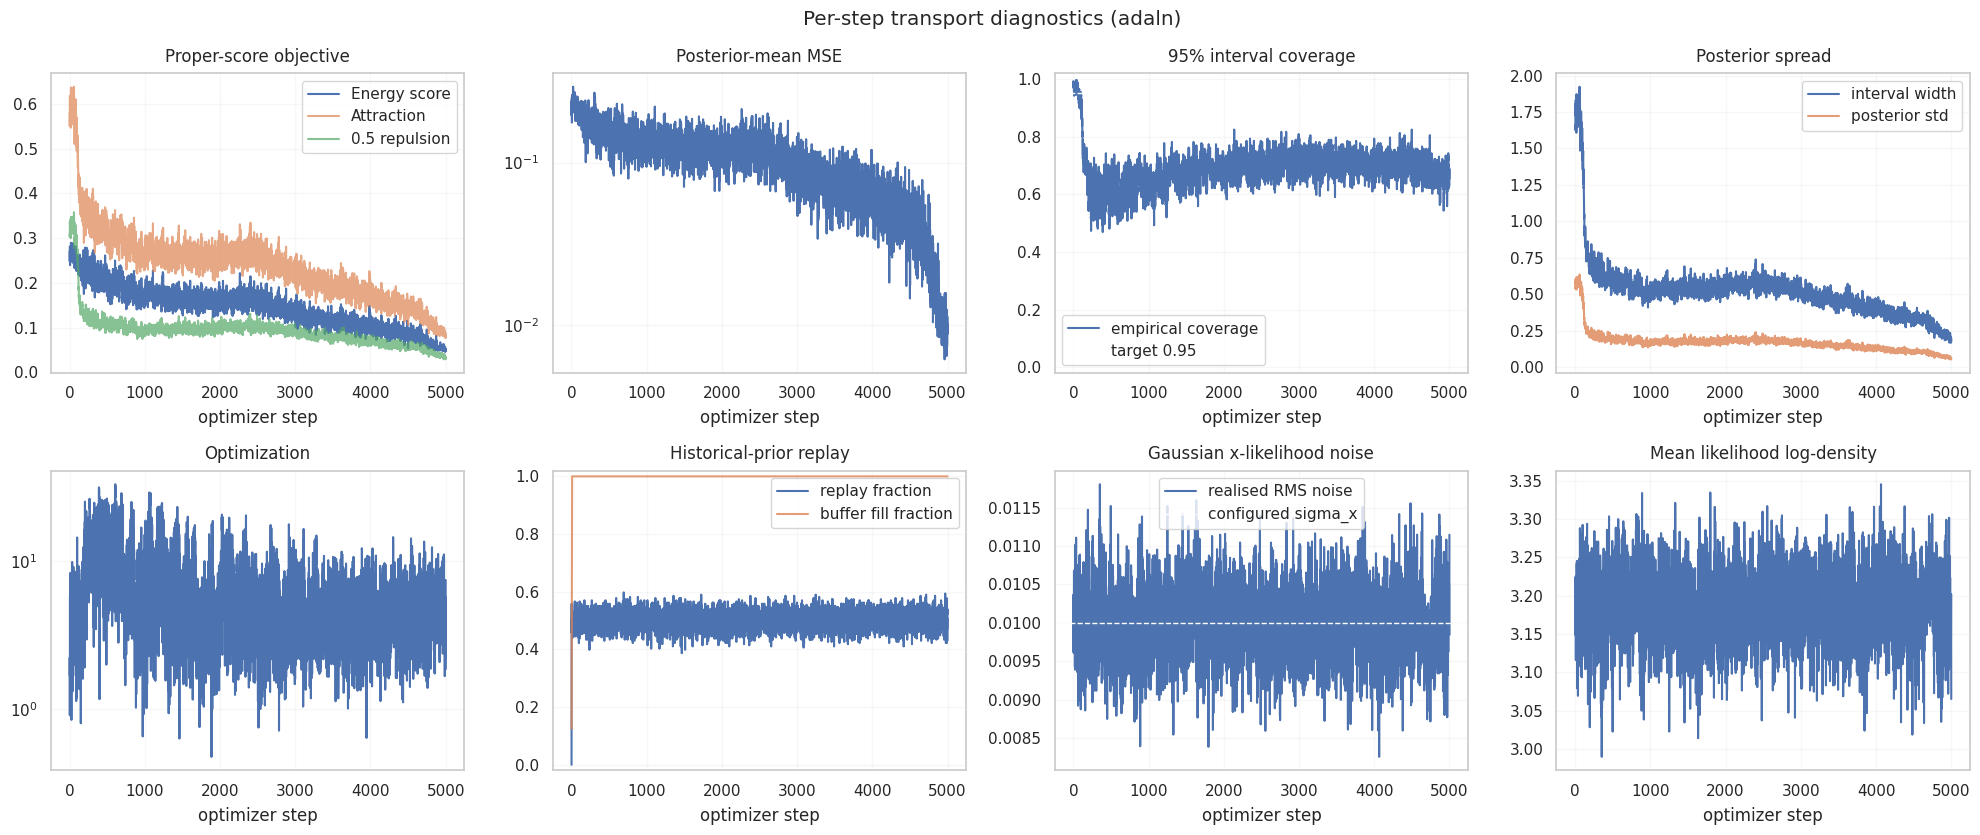

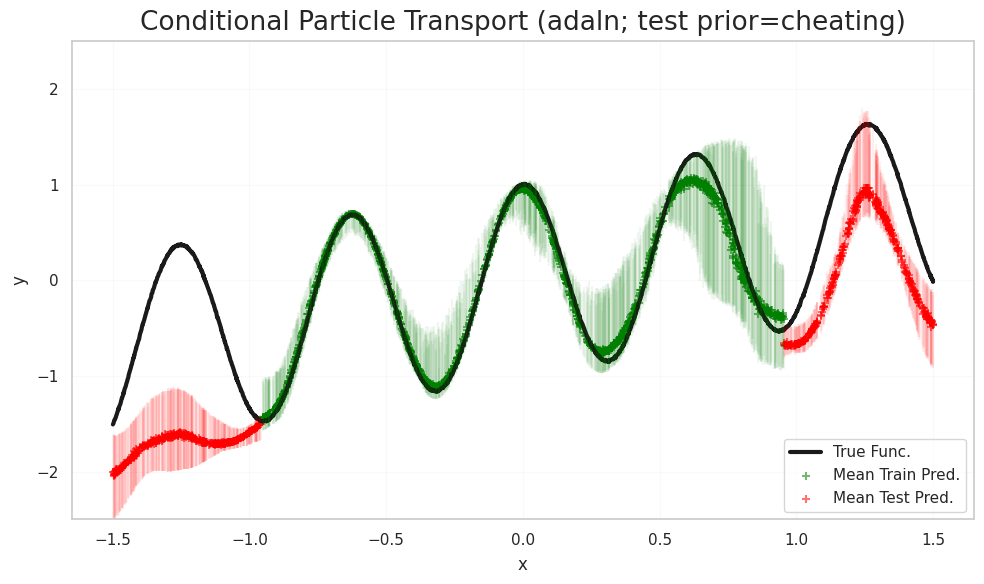

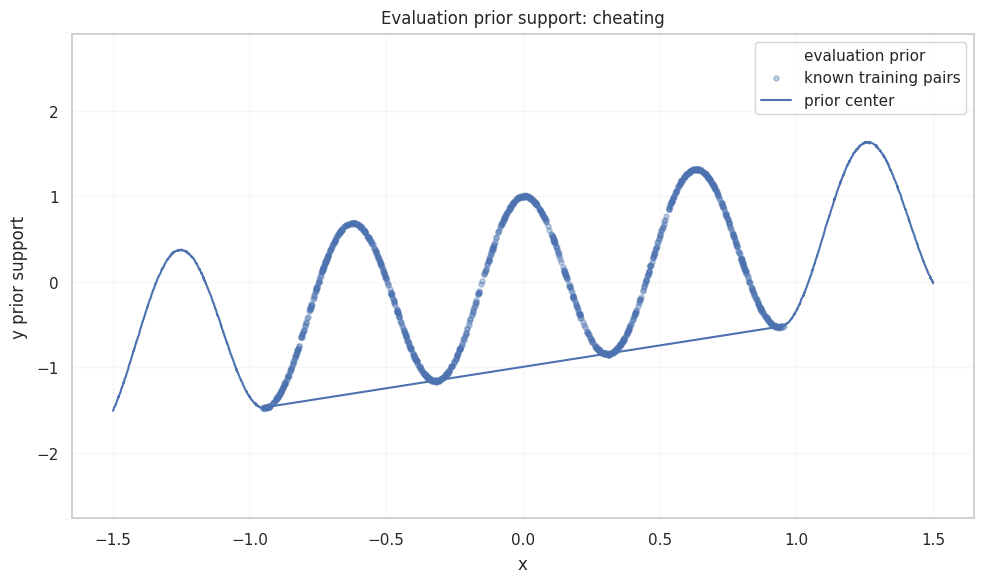

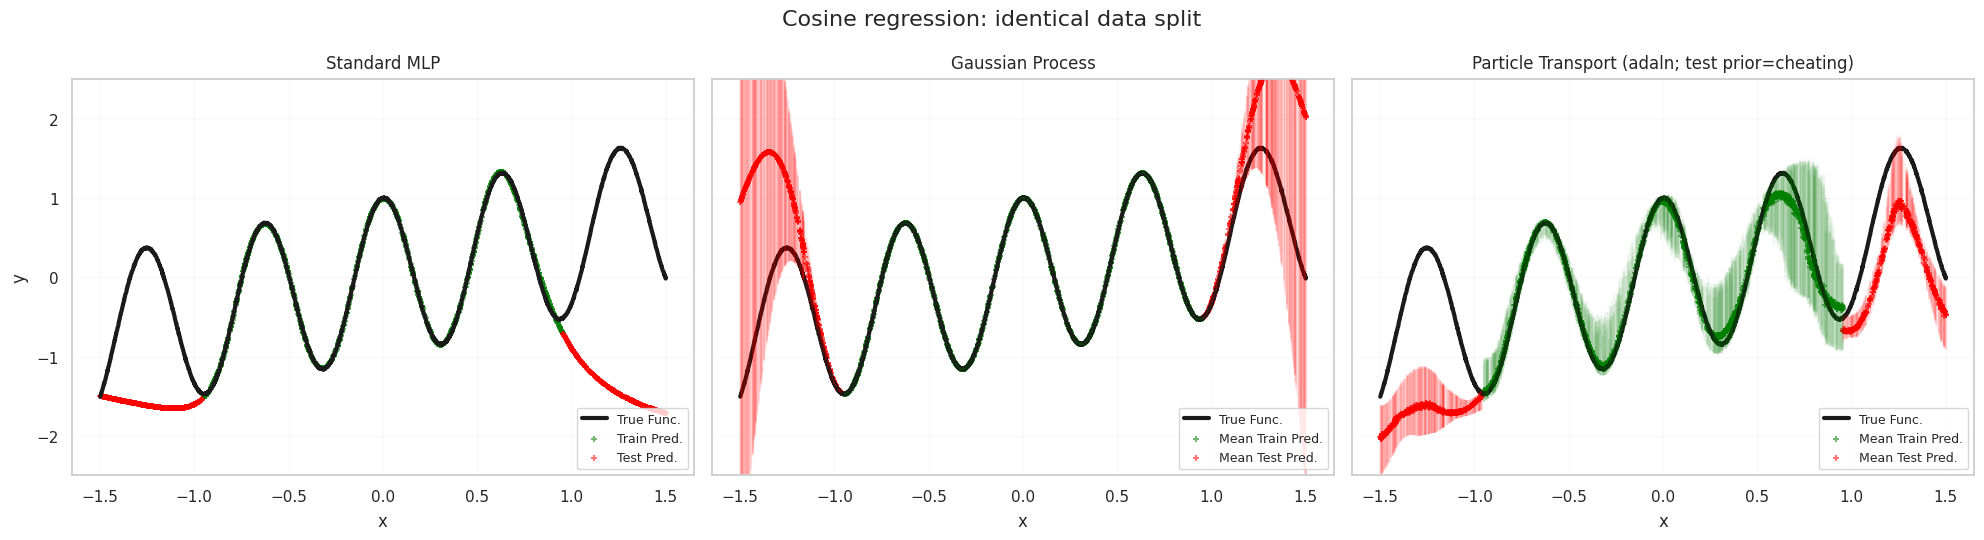

Saved outputs to /Users/ddrous/Projects/HiddenRep/limit_weight_space/plots/cosine_transport


In [ ]:
if __name__ == "__main__":
    validate_config(CFG)
    plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})
    out = Path(CFG.output_dir); out.mkdir(parents=True, exist_ok=True)

    X_train, Y_train, X_test, Y_test = gen_data(CFG)
    scaling = make_scaling(X_train, Y_train, CFG)
    print_experiment_setup(X_train, Y_train, X_test, Y_test, scaling, CFG)

    # Build EVERY model before training so sizes are known before the first optimization/fit call.
    transport_init = ConditionalParticleTransport(CFG, scaling, key=jax.random.key(CFG.seed))
    nn_init = StandardMLP(CFG, key=jax.random.key(CFG.seed))
    gp_init = make_gp(CFG)
    print_model_parameter_counts(transport_init, nn_init, gp_init, len(X_train))

    print("\n--- training particle transport ---")
    transport, history = train_transport(
        X_train, Y_train, scaling, CFG, model=transport_init
    )

    # Keep train diagnostics on the widest support to avoid self-informed train priors.
    # Test evaluation uses the configured prior mode. The default cheating/oracle mode
    # intentionally uses Y_test to centre each test-time prior.
    tr_train = predict_transport(
        transport, X_train, scaling, CFG, seed=CFG.seed + 30_001,
        x_train_reference=X_train, y_train_reference=Y_train, prior_mode="widest",
    )
    tr_test = predict_transport(
        transport, X_test, scaling, CFG, seed=CFG.seed + 30_002,
        x_train_reference=X_train, y_train_reference=Y_train,
        prior_mode=CFG.evaluation_prior_mode,
        y_query_oracle=Y_test if CFG.evaluation_prior_mode == "cheating" else None,
    )
    tr_train_metrics = evaluate_transport(tr_train, Y_train)
    tr_test_metrics = evaluate_transport(tr_test, Y_test)

    print("\n--- training standard MLP ---")
    nn_model = train_mlp(X_train, Y_train, CFG, model=nn_init)
    nn_train, nn_test = predict_mlp(nn_model, X_train), predict_mlp(nn_model, X_test)

    print("\n--- fitting Gaussian Process ---")
    gp = fit_gp(gp_init, X_train, Y_train)
    gp_train, gp_train_std = gp.predict(X_train[:, None], return_std=True)
    gp_test, gp_test_std = gp.predict(X_test[:, None], return_std=True)

    mse = lambda y, p: float(np.mean((y - p) ** 2))
    metrics = {
        "particle_transport": {"train": tr_train_metrics, "test": tr_test_metrics},
        "mlp": {"train_mse": mse(Y_train, nn_train), "test_mse": mse(Y_test, nn_test)},
        "gp": {
            "train_mse": mse(Y_train, gp_train), "test_mse": mse(Y_test, gp_test),
            "train_coverage_95": float(np.mean(np.abs(Y_train - gp_train) <= 1.96 * gp_train_std)),
            "test_coverage_95": float(np.mean(np.abs(Y_test - gp_test) <= 1.96 * gp_test_std)),
        },
        "scaling": asdict(scaling),
        "config": asdict(CFG),
    }
    print("\n--- final same-split comparison ---")
    print(f"MLP       train MSE={metrics['mlp']['train_mse']:.6f} test MSE={metrics['mlp']['test_mse']:.6f}")
    print(f"GP        train MSE={metrics['gp']['train_mse']:.6f} test MSE={metrics['gp']['test_mse']:.6f}")
    print(
        f"Transport train MSE={tr_train_metrics['mse']:.6f} test MSE={tr_test_metrics['mse']:.6f} | "
        f"test ES={tr_test_metrics['energy_score']:.6f} cov95={tr_test_metrics['coverage_95']:.3f} | "
        f"prior={tr_test['prior_mode']} mean-width={tr_test_metrics['mean_prior_width']:.3f}"
    )

    with (out / "metrics.json").open("w") as f: json.dump(metrics, f, indent=2)
    with (out / "training_history.json").open("w") as f: json.dump(history, f, indent=2)
    eqx.tree_serialise_leaves(out / "particle_transport.eqx", transport)

    # These now save AND display inline when CFG.show_plots=True.
    plot_training(history, out / "transport_training_diagnostics.pdf", CFG)
    plot_transport(
        X_train, Y_train, X_test, Y_test, tr_train, tr_test,
        out / "transport_predictions_uncertainty.pdf", CFG,
    )
    plot_evaluation_prior_ranges(
        X_train, Y_train, X_test, tr_test,
        out / "evaluation_prior_ranges.pdf", CFG,
    )
    plot_comparison(
        X_train, Y_train, X_test, Y_test,
        nn_train, nn_test, gp_train, gp_train_std, gp_test, gp_test_std,
        tr_train, tr_test, out / "final_comparison.pdf", CFG,
    )
    print(f"Saved outputs to {out.resolve()}")